# 1 — Importation des librairies

In [40]:
import os
import re
import string
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from ultralytics import YOLO

from sklearn.model_selection import train_test_split

from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
from rouge_score import rouge_scorer

import warnings
warnings.filterwarnings("ignore")

In [41]:
import nltk
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)

True

In [42]:
# 1. DEVICE — automatically picks MPS (M5 GPU), CUDA, or CPU
# =============================================================================
if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
    print("Using Apple MPS GPU (Metal)")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
    print("Using CUDA GPU")
else:
    DEVICE = torch.device("cpu")
    print("Using CPU")

Using Apple MPS GPU (Metal)


# 2 — Lire les données

In [43]:
TOKEN_FILE = r"../data/Flickr8k_text/Flickr8k.token.txt"
IMAGE_FOLDER = r"../data/Flicker8k_Dataset"
 
# ── Manual override if auto-detection fails ───────────────────────────────────
# TOKEN_FILE   = "/full/path/to/Flickr8k.token.txt"
# IMAGE_FOLDER = "/full/path/to/Flicker8k_Dataset"
 
print("TOKEN_FILE   :", TOKEN_FILE   or "NOT FOUND")
print("IMAGE_FOLDER :", IMAGE_FOLDER or "NOT FOUND")
 
if not TOKEN_FILE or not IMAGE_FOLDER:
    raise FileNotFoundError("Set TOKEN_FILE and IMAGE_FOLDER manually above.")

TOKEN_FILE   : ../data/Flickr8k_text/Flickr8k.token.txt
IMAGE_FOLDER : ../data/Flicker8k_Dataset


In [44]:
# ⚠️  Adaptez ces chemins à votre arborescence

data_textuel = pd.read_csv(TOKEN_FILE, sep="\t", header=None, names=["image_id", "caption"])

# 3 — Nettoyage des captions

In [45]:
def nettoyer_texte(caption):
    """
    Normalise une caption :
      1. minuscule
      2. supprime les chiffres
      3. supprime la ponctuation  (AVANT d'ajouter <start>/<end> pour ne pas les supprimer)
      4. supprime les espaces multiples
      5. ajoute les tokens de séquence
    """
    caption = caption.lower()
    caption = re.sub(r"\d+", "", caption)
    caption = caption.translate(str.maketrans("", "", string.punctuation))
    caption = re.sub(r"\s+", " ", caption).strip()
    return f"<start> {caption} <end>"

data_textuel["caption"] = data_textuel["caption"].apply(nettoyer_texte)

# Extraire le nom de fichier propre ("img123.jpg#0" → "img123.jpg")
data_textuel["image"] = data_textuel["image_id"].str.split("#").str[0]

# Corriger les extensions mal formées (.jpg.1 → .jpg)
data_textuel["image"] = data_textuel["image"].str.replace(
    r"\.jpg\.\d+$", ".jpg", regex=True
)

# On ne garde que les colonnes utiles
data_textuel = data_textuel[["image", "caption"]]
print(data_textuel.shape)
data_textuel.head()

(40460, 2)


,image,caption
0,1000268201_693b08cb0e.jpg,<start> a child in a pink dress is climbing up...
1,1000268201_693b08cb0e.jpg,<start> a girl going into a wooden building <end>
2,1000268201_693b08cb0e.jpg,<start> a little girl climbing into a wooden p...
3,1000268201_693b08cb0e.jpg,<start> a little girl climbing the stairs to h...
4,1000268201_693b08cb0e.jpg,<start> a little girl in a pink dress going in...


# 4 — Extraction des features — backbone YOLOv8

In [46]:
# ── FIX : utiliser un hook forward au lieu de nn.Sequential ──────────────
# nn.Sequential(*children()[:-3]) casse l'architecture YOLOv8 car ses
# modules internes ne sont pas de simples séquences empilables.
# La bonne approche : capturer la sortie d'une couche intermédiaire
# via register_forward_hook, puis faire passer l'image dans le modèle complet.

yolo = YOLO("yolov8n.pt")
yolo_model = yolo.model.eval().to(DEVICE)

# On gèle tous les poids — on n'entraîne que le captioning LSTM
for p in yolo_model.parameters():
    p.requires_grad = False

# Pool global pour produire un vecteur de taille fixe
pool = nn.AdaptiveAvgPool2d((1, 1)).to(DEVICE)

# Hook : on capture la sortie de l'avant-dernière couche (index -2)
_hook_output = {}

def _hook_fn(module, input, output):
    # YOLOv8 peut retourner un Tensor ou une liste ; on normalise
    if isinstance(output, (list, tuple)):
        _hook_output["feat"] = output[-1]
    else:
        _hook_output["feat"] = output

# Identifier le bon module : le backbone de YOLOv8n est yolo.model.model[9]
# (le C2f final avant le neck SPPF). On attache le hook là.
backbone_layer = yolo_model.model[9]   # couche 9 = dernier bloc C2f du backbone
hook_handle = backbone_layer.register_forward_hook(_hook_fn)

print("Hook attaché sur :", backbone_layer.__class__.__name__)
print("Backbone YOLOv8 chargé et figé.")

Hook attaché sur : SPPF
Backbone YOLOv8 chargé et figé.


In [47]:
# Transformations pour préparer les images pour YOLOv8
transform = transforms.Compose([
    transforms.Resize((640, 640)),   # YOLOv8 attend du 640×640
    transforms.ToTensor(),           # [0, 1]
])

def preprocessing_images(path_image):
    """Charge une image et la convertit en tensor batch (1, 3, 640, 640)."""
    img = Image.open(path_image).convert("RGB")
    tensor = transform(img).unsqueeze(0)   # (1, 3, 640, 640)
    return tensor


def extraction_features(path_image):
    """
    Retourne un vecteur numpy 1-D de features extraites du backbone YOLOv8.
    Le hook capture la sortie de la couche backbone_layer après le forward pass.
    """
    img_tensor = preprocessing_images(path_image).to(DEVICE)

    with torch.no_grad():
        yolo_model(img_tensor)          # déclenche le hook
        feat = _hook_output["feat"]     # (1, C, H, W) ou liste

    # Normaliser : s'assurer qu'on a un Tensor 4-D
    if isinstance(feat, (list, tuple)):
        feat = feat[-1]
    if feat.dim() == 3:
        feat = feat.unsqueeze(0)

    feat = pool(feat)        # (1, C, 1, 1)
    feat = feat.flatten()    # vecteur 1-D

    return feat.cpu().numpy()

# 5 — Extraction des features pour toutes les images

In [48]:
image_features = {}
images_uniques = data_textuel["image"].unique()
print(f"Nombre d'images uniques : {len(images_uniques)}")

for i, img_name in enumerate(images_uniques):
    path = os.path.join(IMAGE_FOLDER, img_name)
    try:
        image_features[img_name] = extraction_features(path)
    except Exception as e:
        print(f"Erreur [{img_name}] : {e}")

    if (i + 1) % 500 == 0:
        print(f"  {i+1}/{len(images_uniques)} images traitées…")

print(f"\nFeatures extraites pour {len(image_features)} images.")

# Vérifier la dimension d'un vecteur
premiere_cle = list(image_features.keys())[0]
print("Dimension feature :", image_features[premiere_cle].shape)

Nombre d'images uniques : 8092
  500/8092 images traitées…
  1000/8092 images traitées…
  1500/8092 images traitées…
  2000/8092 images traitées…
  2500/8092 images traitées…
  3000/8092 images traitées…
  3500/8092 images traitées…
  4000/8092 images traitées…
  4500/8092 images traitées…
  5000/8092 images traitées…
  5500/8092 images traitées…
  6000/8092 images traitées…
  6500/8092 images traitées…
  7000/8092 images traitées…
  7500/8092 images traitées…
  8000/8092 images traitées…

Features extraites pour 8092 images.
Dimension feature : (256,)


# 6 — Grouper les captions par image

In [49]:
# Grouper les captions par image (5 par image dans Flickr8k)
captions_par_image = (
    data_textuel
    .groupby("image")["caption"]
    .apply(list)
    .reset_index()
)
print(captions_par_image.shape)
captions_par_image.head()

(8092, 2)


,image,caption
0,1000268201_693b08cb0e.jpg,[<start> a child in a pink dress is climbing u...
1,1001773457_577c3a7d70.jpg,[<start> a black dog and a spotted dog are fig...
2,1002674143_1b742ab4b8.jpg,[<start> a little girl covered in paint sits i...
3,1003163366_44323f5815.jpg,[<start> a man lays on a bench while his dog s...
4,1007129816_e794419615.jpg,[<start> a man in an orange hat starring at so...


Image : 1000268201_693b08cb0e.jpg


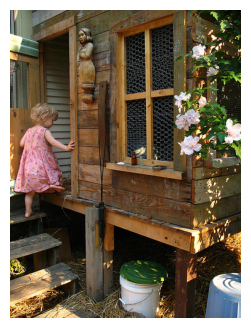

  <start> a child in a pink dress is climbing up a set of stairs in an entry way <end>
  <start> a girl going into a wooden building <end>
  <start> a little girl climbing into a wooden playhouse <end>
  <start> a little girl climbing the stairs to her playhouse <end>
  <start> a little girl in a pink dress going into a wooden cabin <end>
------------------------------------------------------------
Image : 1001773457_577c3a7d70.jpg


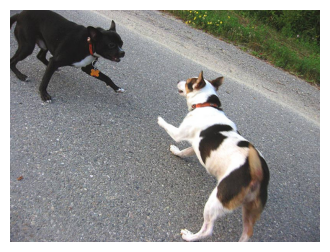

  <start> a black dog and a spotted dog are fighting <end>
  <start> a black dog and a tricolored dog playing with each other on the road <end>
  <start> a black dog and a white dog with brown spots are staring at each other in the street <end>
  <start> two dogs of different breeds looking at each other on the road <end>
  <start> two dogs on pavement moving toward each other <end>
------------------------------------------------------------
Image : 1002674143_1b742ab4b8.jpg


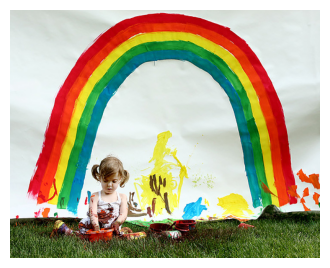

  <start> a little girl covered in paint sits in front of a painted rainbow with her hands in a bowl <end>
  <start> a little girl is sitting in front of a large painted rainbow <end>
  <start> a small girl in the grass plays with fingerpaints in front of a white canvas with a rainbow on it <end>
  <start> there is a girl with pigtails sitting in front of a rainbow painting <end>
  <start> young girl with pigtails painting outside in the grass <end>
------------------------------------------------------------


In [50]:
# Visualiser quelques exemples
for i, row in captions_par_image.head(3).iterrows():
    print("Image :", row["image"])
    img = Image.open(os.path.join(IMAGE_FOLDER, row["image"]))
    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.axis("off")
    plt.show()
    for cap in row["caption"]:
        print(" ", cap)
    print("-" * 60)

# 7 — Sauvegarder les données intermédiaires

In [51]:
data_textuel.to_csv("captions_clean.csv", index=False)
captions_par_image.to_csv("captions_by_image.csv", index=False)

with open("image_features.pkl", "wb") as f:
    pickle.dump(image_features, f)

print("Fichiers sauvegardés : captions_clean.csv, captions_by_image.csv, image_features.pkl")

Fichiers sauvegardés : captions_clean.csv, captions_by_image.csv, image_features.pkl


# 8 — Train / Validation / Test split

In [52]:
images_list = captions_par_image["image"].tolist()

train_imgs, test_imgs = train_test_split(images_list, test_size=0.2,  random_state=42)
train_imgs, val_imgs  = train_test_split(train_imgs,  test_size=0.1,  random_state=42)

print(f"Train : {len(train_imgs)} | Val : {len(val_imgs)} | Test : {len(test_imgs)}")

# Dictionnaire image → liste de captions
captions_dict = dict(zip(captions_par_image["image"], captions_par_image["caption"]))

Train : 5825 | Val : 648 | Test : 1619


# 9 — Construire le vocabulaire

In [53]:
# Collecter toutes les captions du set d'entraînement uniquement
all_captions = []
for img in train_imgs:
    all_captions.extend(captions_dict[img])

# Comptage des fréquences
compteur = Counter()
for caption in all_captions:
    for mot in caption.split():
        compteur[mot] += 1

# Tokens spéciaux : <pad>=0, <start>=1, <end>=2, <unk>=3
SEUIL_FREQ = 5
tokens_speciaux = ["<pad>", "<start>", "<end>", "<unk>"]
vocab_list = tokens_speciaux + [
    mot for mot, freq in compteur.items()
    if freq >= SEUIL_FREQ and mot not in tokens_speciaux
]

word2idx = {mot: i for i, mot in enumerate(vocab_list)}
idx2word = {i: mot for mot, i in word2idx.items()}
vocab_size = len(word2idx)

print(f"Taille du vocabulaire : {vocab_size}")

max_length = max(len(cap.split()) for cap in all_captions)
print(f"Longueur maximale de caption : {max_length}")

Taille du vocabulaire : 2503
Longueur maximale de caption : 37


# 10 — Encoder les captions + padding

In [54]:
# ── FIX : renommé pad_seq pour ne pas écraser torch.nn.utils.rnn.pad_sequence ──

def encoder_caption(caption):
    """Convertit une caption en liste d'indices (<unk> pour les mots hors vocab)."""
    unk_idx = word2idx["<unk>"]
    return [word2idx.get(mot, unk_idx) for mot in caption.split()]


def pad_seq(indices, longueur_max):
    """Pad ou tronque une séquence d'indices à longueur_max (0 = <pad>)."""
    padded = [0] * longueur_max
    for i, idx in enumerate(indices[:longueur_max]):
        padded[i] = idx
    return padded

In [55]:
# Construction des tensors d'entraînement (teacher forcing)
def build_tensors(img_list):
    """
    Pour chaque image et chaque caption, génère des paires (image_feat, seq_in, mot_cible).
    Retourne trois tensors PyTorch.
    """
    X_img, X_txt, Y = [], [], []

    for img in img_list:
        if img not in image_features:
            continue
        feature = image_features[img]

        for caption in captions_dict[img]:
            indices = encoder_caption(caption)

            for t in range(1, len(indices)):
                seq_in    = pad_seq(indices[:t], max_length)
                mot_cible = indices[t]

                X_img.append(feature)
                X_txt.append(seq_in)
                Y.append(mot_cible)

    X_img_t = torch.tensor(np.array(X_img), dtype=torch.float32)
    X_txt_t = torch.tensor(np.array(X_txt), dtype=torch.long)
    Y_t     = torch.tensor(np.array(Y),     dtype=torch.long)
    return X_img_t, X_txt_t, Y_t


X_img_tensor, X_txt_tensor, y_tensor = build_tensors(train_imgs)
X_img_val, X_txt_val, y_val          = build_tensors(val_imgs)

print(f"Train — X_img : {X_img_tensor.shape} | X_txt : {X_txt_tensor.shape} | y : {y_tensor.shape}")
print(f"Val   — X_img : {X_img_val.shape}    | X_txt : {X_txt_val.shape}    | y : {y_val.shape}")

Train — X_img : torch.Size([343471, 256]) | X_txt : torch.Size([343471, 37]) | y : torch.Size([343471])
Val   — X_img : torch.Size([38193, 256])    | X_txt : torch.Size([38193, 37])    | y : torch.Size([38193])


# 11 — Dataset et DataLoader

In [56]:
class CaptioningDataset(Dataset):
    """Dataset PyTorch pour l'image captioning."""

    def __init__(self, X_img, X_txt, y):
        self.X_img = X_img
        self.X_txt = X_txt
        self.y     = y

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X_img[idx], self.X_txt[idx], self.y[idx]


train_dataset = CaptioningDataset(X_img_tensor, X_txt_tensor, y_tensor)
val_dataset   = CaptioningDataset(X_img_val, X_txt_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=256, shuffle=False, num_workers=0)

print(f"Batches train : {len(train_loader)} | Batches val : {len(val_loader)}")

Batches train : 2684 | Batches val : 150


# 12 — Architecture du modèle LSTM

In [57]:
# Dimension de sortie du backbone YOLOv8 (détectée automatiquement)
feature_dim = X_img_tensor.shape[1]
embed_dim   = 256
hidden_dim  = 256

print(f"feature_dim : {feature_dim} | embed_dim : {embed_dim} | hidden_dim : {hidden_dim}")

feature_dim : 256 | embed_dim : 256 | hidden_dim : 256


In [58]:
class ImageCaptioningLSTM(nn.Module):
    """
    Architecture :
      - Branche image  : Dropout → Linear(feature_dim → embed_dim) → ReLU
      - Branche texte  : Embedding(vocab_size, embed_dim) → Dropout → LSTM
      - Fusion         : addition des deux vecteurs
      - Sortie         : Linear(embed_dim → vocab_size)
    """

    def __init__(self, vocab_size, feature_dim, embed_dim, hidden_dim, dropout=0.5):
        super().__init__()

        # Branche image
        self.image_proj = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(feature_dim, embed_dim),
            nn.ReLU(),
        )

        # Branche texte
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.dropout   = nn.Dropout(dropout)

        # LSTM
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=1,
            batch_first=True
        )

        # Décodeur
        self.decoder = nn.Sequential(
            nn.Linear(hidden_dim, embed_dim),
            nn.ReLU(),
        )
        self.output_layer = nn.Linear(embed_dim, vocab_size)

    def forward(self, img_features, captions):
        # Branche image : (batch, feature_dim) → (batch, embed_dim)
        img_emb = self.image_proj(img_features)

        # Branche texte : (batch, seq_len) → (batch, seq_len, embed_dim)
        txt_emb = self.dropout(self.embedding(captions))

        # LSTM : → (batch, seq_len, hidden_dim) ; on prend le dernier pas de temps
        lstm_out, _ = self.lstm(txt_emb)
        lstm_out = lstm_out[:, -1, :]           # (batch, hidden_dim)

        # Fusion par addition
        fused  = img_emb + lstm_out
        out    = self.decoder(fused)
        logits = self.output_layer(out)         # (batch, vocab_size)

        return logits


model = ImageCaptioningLSTM(
    vocab_size=vocab_size,
    feature_dim=feature_dim,
    embed_dim=embed_dim,
    hidden_dim=hidden_dim,
    dropout=0.5,
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f"\nParamètres entraînables : {total_params:,}")

ImageCaptioningLSTM(
  (image_proj): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=256, out_features=256, bias=True)
    (2): ReLU()
  )
  (embedding): Embedding(2503, 256, padding_idx=0)
  (dropout): Dropout(p=0.5, inplace=False)
  (lstm): LSTM(256, 256, batch_first=True)
  (decoder): Sequential(
    (0): Linear(in_features=256, out_features=256, bias=True)
    (1): ReLU()
  )
  (output_layer): Linear(in_features=256, out_features=2503, bias=True)
)

Paramètres entraînables : 1,941,959


# 13 — Optimizer et fonction de perte

In [59]:
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# ignore_index=0 : on n'optimise pas sur le padding
criterion = nn.CrossEntropyLoss(ignore_index=0)

# 14 — Entraînement

In [ ]:
EPOCHS   = 20
history  = {"loss": [], "val_loss": []}
best_loss = float("inf")

for epoch in range(1, EPOCHS + 1):
    # ── Phase entraînement ──────────────────────────────────────
    model.train()
    perte_train = 0.0

    for img_feat, txt_seq, cible in train_loader:
        img_feat = img_feat.to(DEVICE)
        txt_seq  = txt_seq.to(DEVICE)
        cible    = cible.to(DEVICE)

        optimizer.zero_grad()
        logits = model(img_feat, txt_seq)
        loss   = criterion(logits, cible)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()
        perte_train += loss.item()

    perte_train /= len(train_loader)

    # ── Phase validation ────────────────────────────────────────
    model.eval()
    perte_val = 0.0

    with torch.no_grad():
        for img_feat, txt_seq, cible in val_loader:
            img_feat = img_feat.to(DEVICE)
            txt_seq  = txt_seq.to(DEVICE)
            cible    = cible.to(DEVICE)
            logits   = model(img_feat, txt_seq)
            perte_val += criterion(logits, cible).item()

    perte_val /= len(val_loader)

    history["loss"].append(perte_train)
    history["val_loss"].append(perte_val)

    print(f"Epoch {epoch:02d}/{EPOCHS} | Loss : {perte_train:.4f} | Val Loss : {perte_val:.4f}")

    # Sauvegarder le meilleur modèle (sur val_loss)
    if perte_val < best_loss:
        best_loss = perte_val
        torch.save({
            "model_state_dict": model.state_dict(),
            "word2idx": word2idx,
            "idx2word": idx2word,
            "vocab_size": vocab_size,
            "max_length": max_length,
            "feature_dim": feature_dim,
            "embed_dim": embed_dim,
            "hidden_dim": hidden_dim,
        }, "best_model.pt")
        print(f"  → Meilleur modèle sauvegardé (val_loss={best_loss:.4f})")

Epoch 01/20 | Loss : 5.1249 | Val Loss : 4.6171
  → Meilleur modèle sauvegardé (val_loss=4.6171)
Epoch 02/20 | Loss : 4.2999 | Val Loss : 4.1220
  → Meilleur modèle sauvegardé (val_loss=4.1220)
Epoch 03/20 | Loss : 3.9013 | Val Loss : 3.8606
  → Meilleur modèle sauvegardé (val_loss=3.8606)
Epoch 04/20 | Loss : 3.7076 | Val Loss : 3.7134
  → Meilleur modèle sauvegardé (val_loss=3.7134)
Epoch 05/20 | Loss : 3.5630 | Val Loss : 3.5845
  → Meilleur modèle sauvegardé (val_loss=3.5845)
Epoch 06/20 | Loss : 3.4523 | Val Loss : 3.4923
  → Meilleur modèle sauvegardé (val_loss=3.4923)
Epoch 07/20 | Loss : 3.3675 | Val Loss : 3.4654
  → Meilleur modèle sauvegardé (val_loss=3.4654)
Epoch 08/20 | Loss : 3.2986 | Val Loss : 3.3803
  → Meilleur modèle sauvegardé (val_loss=3.3803)
Epoch 09/20 | Loss : 3.2399 | Val Loss : 3.4115
Epoch 10/20 | Loss : 3.1893 | Val Loss : 3.2512
  → Meilleur modèle sauvegardé (val_loss=3.2512)
Epoch 11/20 | Loss : 3.1453 | Val Loss : 3.2918
Epoch 12/20 | Loss : 3.1047 | V

# 15 — Courbe d'entraînement

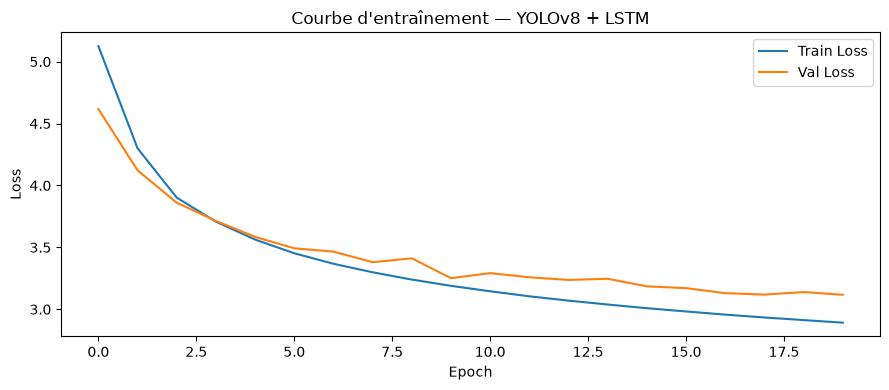

In [61]:
plt.figure(figsize=(9, 4))
plt.plot(history["loss"],     label="Train Loss")
plt.plot(history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Courbe d'entraînement — YOLOv8 + LSTM")
plt.legend()
plt.tight_layout()
plt.show()

# 16 — Sauvegarder le modèle final

In [62]:
torch.save({
    "model_state_dict": model.state_dict(),
    "word2idx": word2idx,
    "idx2word": idx2word,
    "vocab_size": vocab_size,
    "max_length": max_length,
    "feature_dim": feature_dim,
    "embed_dim": embed_dim,
    "hidden_dim": hidden_dim,
}, "model_yolo_lstm.pt")

tokenizer_data = {
    "word2idx": word2idx,
    "idx2word": idx2word,
    "vocab_size": vocab_size,
    "max_length": max_length,
}
with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer_data, f)

print("Modèle final  : model_yolo_lstm.pt")
print("Meilleur modèle: best_model.pt")
print("Tokenizer     : tokenizer.pkl")

Modèle final  : model_yolo_lstm.pt
Meilleur modèle: best_model.pt
Tokenizer     : tokenizer.pkl


# 17 — Génération de légendes

In [63]:
def generate_caption(model, feature, word2idx, idx2word, max_length, device=DEVICE):
    """
    Génère une caption mot par mot (greedy search).
    feature : vecteur numpy 1-D de features YOLOv8.
    """
    model.eval()
    in_text = [word2idx["<start>"]]
    img_tensor = torch.tensor(feature, dtype=torch.float32).unsqueeze(0).to(device)

    with torch.no_grad():
        for _ in range(max_length):
            seq = pad_seq(in_text, max_length)
            seq_tensor = torch.tensor([seq], dtype=torch.long).to(device)

            logits   = model(img_tensor, seq_tensor)     # (1, vocab_size)
            next_idx = logits.argmax(dim=-1).item()
            mot      = idx2word.get(next_idx, "<unk>")

            if mot == "<end>":
                break
            in_text.append(next_idx)

    mots = [idx2word.get(i, "<unk>") for i in in_text[1:]]
    return " ".join(mots)

# 18 — Prédictions sur le set de test

In [64]:
references  = []
hypotheses  = []

for img in test_imgs:
    if img not in image_features:
        continue

    pred = generate_caption(model, image_features[img], word2idx, idx2word, max_length)
    hypotheses.append(pred)
    references.append(captions_dict[img])

print(f"Images évaluées : {len(hypotheses)}")
print("\nExemple :")
print("  Référence 0 :", references[0][0])
print("  Prédiction  :", hypotheses[0])

Images évaluées : 1619

Exemple :
  Référence 0 : <start> a downhill skier in black catches a tiny bit of air <end>
  Prédiction  : a man in a red jacket is skiing down a snowy hill


# 19 — Évaluation BLEU

In [65]:
refs_bleu = [[ref.split() for ref in refs] for refs in references]
hyps_bleu = [pred.split() for pred in hypotheses]

smooth = SmoothingFunction().method1

bleu1 = corpus_bleu(refs_bleu, hyps_bleu, weights=(1,0,0,0),             smoothing_function=smooth)
bleu2 = corpus_bleu(refs_bleu, hyps_bleu, weights=(0.5,0.5,0,0),         smoothing_function=smooth)
bleu3 = corpus_bleu(refs_bleu, hyps_bleu, weights=(0.33,0.33,0.33,0),    smoothing_function=smooth)
bleu4 = corpus_bleu(refs_bleu, hyps_bleu, weights=(0.25,0.25,0.25,0.25), smoothing_function=smooth)

print(f"BLEU-1 : {bleu1:.4f}")
print(f"BLEU-2 : {bleu2:.4f}")
print(f"BLEU-3 : {bleu3:.4f}")
print(f"BLEU-4 : {bleu4:.4f}")

BLEU-1 : 0.4997
BLEU-2 : 0.3181
BLEU-3 : 0.1938
BLEU-4 : 0.1176


# 20 — Évaluation ROUGE

In [66]:
scorer_rouge = rouge_scorer.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=True)

rouge1_scores, rouge2_scores, rougeL_scores = [], [], []

for img, pred in zip(test_imgs, hypotheses):
    if img not in captions_dict:
        continue
    refs = captions_dict[img]

    best_r1, best_r2, best_rL = 0.0, 0.0, 0.0
    for ref in refs:
        s = scorer_rouge.score(ref, pred)
        best_r1 = max(best_r1, s["rouge1"].fmeasure)
        best_r2 = max(best_r2, s["rouge2"].fmeasure)
        best_rL = max(best_rL, s["rougeL"].fmeasure)

    rouge1_scores.append(best_r1)
    rouge2_scores.append(best_r2)
    rougeL_scores.append(best_rL)

print(f"ROUGE-1 : {sum(rouge1_scores)/len(rouge1_scores):.4f}")
print(f"ROUGE-2 : {sum(rouge2_scores)/len(rouge2_scores):.4f}")
print(f"ROUGE-L : {sum(rougeL_scores)/len(rougeL_scores):.4f}")

ROUGE-1 : 0.3839
ROUGE-2 : 0.1604
ROUGE-L : 0.3557


# 21 — Résumé des métriques

In [67]:
print("=" * 35)
print("       Résumé des métriques")
print("=" * 35)
print(f"  BLEU-1  : {bleu1:.4f}")
print(f"  BLEU-2  : {bleu2:.4f}")
print(f"  BLEU-3  : {bleu3:.4f}")
print(f"  BLEU-4  : {bleu4:.4f}")
print("-" * 35)
print(f"  ROUGE-1 : {sum(rouge1_scores)/len(rouge1_scores):.4f}")
print(f"  ROUGE-2 : {sum(rouge2_scores)/len(rouge2_scores):.4f}")
print(f"  ROUGE-L : {sum(rougeL_scores)/len(rougeL_scores):.4f}")
print("=" * 35)

       Résumé des métriques
  BLEU-1  : 0.4997
  BLEU-2  : 0.3181
  BLEU-3  : 0.1938
  BLEU-4  : 0.1176
-----------------------------------
  ROUGE-1 : 0.3839
  ROUGE-2 : 0.1604
  ROUGE-L : 0.3557
